# Phase C — Building the Three TDP-43 Compartments

Three concentric zones are built around each nucleus centroid to measure TDP-43:
1. **Nucleus** (eroded disk, r≈4.5 µm) — nuclear TDP-43 signal
2. **Nuclear-adjacent ring** (annulus 4.5–9 µm) — peri-nuclear TDP-43
3. **Cytoplasm annulus** (annulus 9–18 µm, neighbour-excluded) — cytoplasmic TDP-43

The N:C ratio = nucleus_mean_bg / cytoplasm_mean_bg is the primary mislocalization readout.

In [ ]:
%matplotlib inline
from pathlib import Path
import numpy as np, pandas as pd, tifffile
import matplotlib.pyplot as plt, matplotlib.colors as mc
from matplotlib.colors import LinearSegmentedColormap
from skimage import morphology, filters
from skimage.morphology import disk, erosion, dilation, label as sklabel
from skimage.measure import regionprops
from skimage.filters import laplace
from scipy.stats import norm

REPO    = Path('/Users/pmihack/claire/hs-array')
UUID    = '5c6bf125-6e0f-41be-a447-b03ff294c9cc'
RUN_DIR = REPO / 'outputs/run_20260806_141727_cyq9'
NUC_PAR = RUN_DIR / f'nuclei_features/{UUID}_nuclei_features.parquet'
TDP_PAR = REPO / f'outputs/tdp43_localization/{UUID}_tdp43_localization_20260806.parquet'
IMG_DIR = REPO / 'data/D28_AB_Rep1' / UUID / 'images'
FIGDIR  = Path('/Users/pmihack/claire/hs-array/resources/iNDI_microscopy_production/notebooks/figures/phase_C')
FIGDIR.mkdir(parents=True, exist_ok=True)

PX_UM = 0.2967; DPI = 300; BG = 'black'; FG = 'white'

# Compartment radii (from 3_tdp43_localization.py)
R_NUC_UM  = 4.5   # µm
R_ADJ_UM  = 9.0   # µm
R_CYTO_UM = 18.0  # µm
R_NUC  = R_NUC_UM  / PX_UM
R_ADJ  = R_ADJ_UM  / PX_UM
R_CYTO = R_CYTO_UM / PX_UM

print(f"Radii: nucleus={R_NUC:.1f}px ({R_NUC_UM}µm)  adj={R_ADJ:.1f}px ({R_ADJ_UM}µm)  cyto={R_CYTO:.1f}px ({R_CYTO_UM}µm)")
print(f"Ring width: {R_ADJ-R_NUC:.1f}px ({R_ADJ_UM-R_NUC_UM:.1f}µm)")
print(f"Cyto width: {R_CYTO-R_ADJ:.1f}px ({R_CYTO_UM-R_ADJ_UM:.1f}µm)")

def build_masks(cy, cx, others_yx, r_nuc, r_adj, r_cyto, y0, y1, x0, x1):
    yy, xx = np.ogrid[y0:y1, x0:x1]
    d2 = (yy - cy)**2 + (xx - cx)**2
    nuc  = d2 <= r_nuc**2
    adj  = (d2 > r_nuc**2) & (d2 <= r_adj**2)
    cyto = (d2 > r_adj**2) & (d2 <= r_cyto**2)
    if len(others_yx):
        other = np.zeros_like(nuc)
        for oy, ox in others_yx:
            other |= (yy-oy)**2 + (xx-ox)**2 <= r_nuc**2
        adj  &= ~other
        cyto &= ~other
    return nuc, adj, cyto

## Step 6 — Nucleus Mask (Eroded)

Demo site: r07c10 f05  (110 nuclei)
TDP-43 best-focus plane: z=1


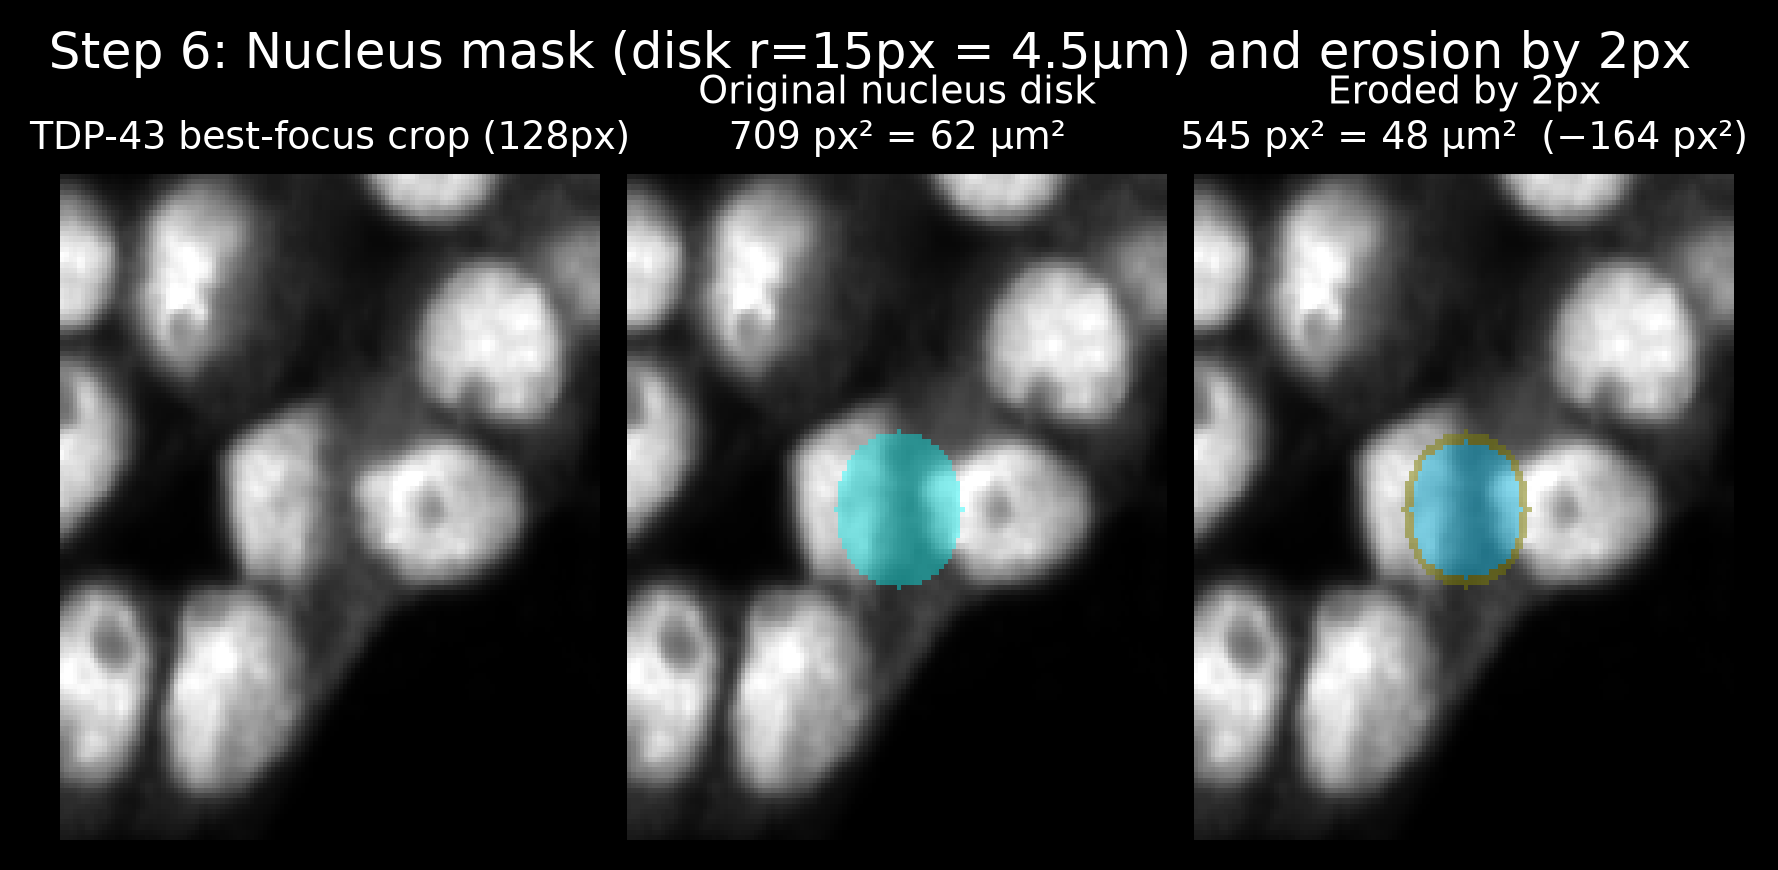

Area loss from erosion: 164 px² (23.1%)


In [2]:
# Load nuclei features and pick one site
df_nuc = pd.read_parquet(NUC_PAR)
df_tdp = pd.read_parquet(TDP_PAR)

# Use well with good density, pick a frame
site_df = df_nuc[(df_nuc.Row==7) & (df_nuc.Column==10) & (df_nuc.Frame==5)].copy()
if len(site_df) < 5:
    # fallback: pick any dense site
    site_counts = df_nuc.groupby(['Row','Column','Frame']).size()
    rc = site_counts.idxmax()
    site_df = df_nuc[(df_nuc.Row==rc[0]) & (df_nuc.Column==rc[1]) & (df_nuc.Frame==rc[2])].copy()
print(f"Demo site: r{site_df.Row.iloc[0]:02d}c{site_df.Column.iloc[0]:02d} f{site_df.Frame.iloc[0]:02d}  ({len(site_df)} nuclei)")

# Load TDP-43 plane for this site
row, col, frame = int(site_df.Row.iloc[0]), int(site_df.Column.iloc[0]), int(site_df.Frame.iloc[0])
tdp_subdir = IMG_DIR / f'r{row:02d}c{col:02d}'
tdp_paths  = sorted(tdp_subdir.glob(f'r{row:02d}c{col:02d}f{frame:02d}p*-ch03t01.tiff'))

if tdp_paths:
    tdp_planes = [tifffile.imread(p).astype(np.float32) for p in tdp_paths]
    focus_scores = [np.var(laplace(p)) for p in tdp_planes]
    best_z = int(np.argmax(focus_scores))
    tdp_img = tdp_planes[best_z]
    print(f"TDP-43 best-focus plane: z={best_z+1}")
else:
    # Fallback: load DAPI z-stack best focus plane
    dapi_paths = sorted(tdp_subdir.glob(f'r{row:02d}c{col:02d}f{frame:02d}p*-ch01t01.tiff'))
    planes = [tifffile.imread(p).astype(np.float32) for p in dapi_paths]
    focus_scores = [np.var(laplace(p)) for p in planes]
    tdp_img = planes[int(np.argmax(focus_scores))]
    print("WARNING: using DAPI as fallback for TDP-43 channel")

# Pick one nucleus for the erosion demo
demo_nuc = site_df.sort_values('area', ascending=False).iloc[3]
cy, cx = float(demo_nuc['centroid-0']), float(demo_nuc['centroid-1'])
R = int(np.ceil(R_CYTO)) + 5

# Build actual nucleus mask from the parquet (re-segment a 128px crop)
CROP = 64  # px half-width for close-up
y0c, y1c = int(max(0, cy-CROP)), int(min(tdp_img.shape[0], cy+CROP))
x0c, x1c = int(max(0, cx-CROP)), int(min(tdp_img.shape[1], cx+CROP))

# For demo: build a disk mask at the nucleus centroid
R_NUC_INT = int(round(R_NUC))
nuc_mask_full = np.zeros(tdp_img.shape, bool)
nuc_mask_full[int(cy), int(cx)] = True
nuc_mask_full = dilation(nuc_mask_full, disk(R_NUC_INT))

# Erode by 2px
nuc_eroded = erosion(nuc_mask_full, disk(2))
area_orig   = nuc_mask_full.sum()
area_eroded = nuc_eroded.sum()

# Show close-up crop
fig, axs = plt.subplots(1, 3, figsize=(7.2, 3.0), facecolor=BG, dpi=DPI)
fig.suptitle(f'Step 6: Nucleus mask (disk r={R_NUC:.0f}px = {R_NUC_UM}µm) and erosion by 2px',
             color=FG, y=1.01)
plt.subplots_adjust(wspace=0.05, top=0.85)
for ax in axs:
    ax.set_facecolor(BG); ax.axis('off')
    for s in ax.spines.values(): s.set_color(FG)

tdp_crop = tdp_img[y0c:y1c, x0c:x1c].astype(np.float32)
nuc_crop = nuc_mask_full[y0c:y1c, x0c:x1c]
ero_crop = nuc_eroded[y0c:y1c, x0c:x1c]
vmin, vmax = np.percentile(tdp_crop, [1, 99.5])

axs[0].imshow(tdp_crop, cmap='gray', vmin=vmin, vmax=vmax, aspect='auto', interpolation='none')
axs[0].set_title(f'TDP-43 best-focus crop (128px)', color=FG, fontsize=9)

axs[1].imshow(tdp_crop, cmap='gray', vmin=vmin, vmax=vmax, aspect='auto', interpolation='none')
ov1 = np.zeros((*tdp_crop.shape, 4), dtype=np.float32)
ov1[nuc_crop] = [0, 1, 1, 0.4]  # cyan fill
axs[1].imshow(ov1, aspect='auto', interpolation='none')
axs[1].set_title(f'Original nucleus disk\n{area_orig} px² = {area_orig*PX_UM**2:.0f} µm²', color=FG, fontsize=9)

axs[2].imshow(tdp_crop, cmap='gray', vmin=vmin, vmax=vmax, aspect='auto', interpolation='none')
ov2 = np.zeros((*tdp_crop.shape, 4), dtype=np.float32)
ov2[ero_crop] = [0, 0.8, 1, 0.4]
ov2[nuc_crop & ~ero_crop] = [0.5, 0.5, 0, 0.5]  # eroded ring = orange
axs[2].imshow(ov2, aspect='auto', interpolation='none')
axs[2].set_title(f'Eroded by 2px\n{area_eroded} px² = {area_eroded*PX_UM**2:.0f} µm²  '
                 f'(−{area_orig-area_eroded} px²)', color=FG, fontsize=9)

fig.savefig(FIGDIR / '01_nucleus_erosion.png', dpi=DPI, bbox_inches='tight', facecolor=BG)
plt.show()
print(f"Area loss from erosion: {area_orig-area_eroded} px² ({(1-area_eroded/area_orig)*100:.1f}%)")

## Step 7 — Nuclear-Adjacent Ring  |  Step 8 — Cytoplasm Annulus

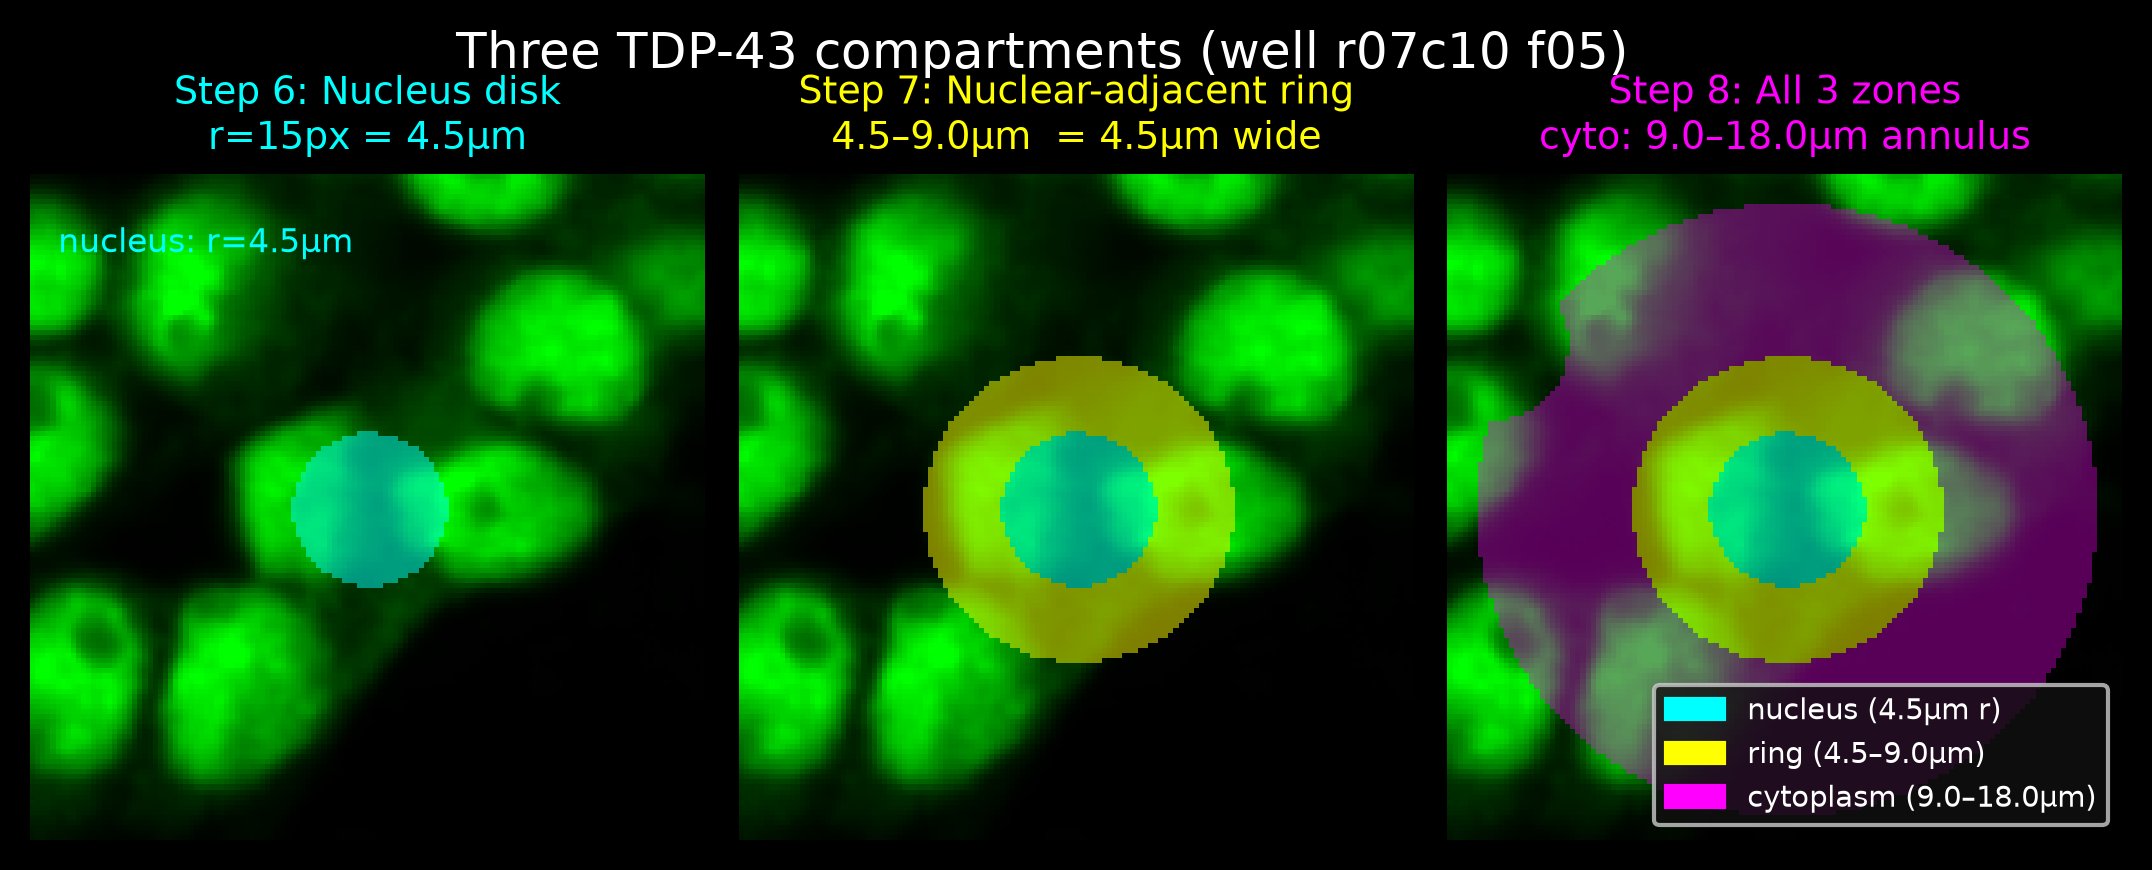

Compartment dimensions:
  nucleus:    r=15.2px (4.5µm)  area=724 px²
  adj ring:   15.2–30.3px (4.5–9.0µm)  area=2163 px²
  cytoplasm:  30.3–60.7px (9.0–18.0µm)  area=8494 px²


In [3]:
# Build all three compartments for the demo cell
y_c, x_c = int(round(cy)), int(round(cx))
R_full = int(np.ceil(R_CYTO)) + 5
y0, y1 = max(0, y_c-R_full), min(tdp_img.shape[0], y_c+R_full)
x0, x1 = max(0, x_c-R_full), min(tdp_img.shape[1], x_c+R_full)

# Get other nuclei centroids in this site (for neighbour exclusion)
others = site_df[site_df.label != demo_nuc.label][['centroid-0','centroid-1']].values.tolist()
others_yx = [(float(oy), float(ox)) for oy, ox in others]

nuc_m, adj_m, cyto_m = build_masks(cy, cx, others_yx, R_NUC, R_ADJ, R_CYTO, y0, y1, x0, x1)
tdp_tile = tdp_img[y0:y1, x0:x1]

# ── Three-zone figure
fig, axs = plt.subplots(1, 3, figsize=(9.0, 3.0), facecolor=BG, dpi=DPI)
fig.suptitle(f'Three TDP-43 compartments (well r{row:02d}c{col:02d} f{frame:02d})', color=FG, y=1.01)
plt.subplots_adjust(wspace=0.05, top=0.85)
for ax in axs: ax.set_facecolor(BG); ax.axis('off'); [s.set_color(FG) for s in ax.spines.values()]

vmin, vmax = np.percentile(tdp_tile, [1, 99.5])
K2G = LinearSegmentedColormap.from_list('k2g', ['black','lime'])

# Panel 1: nucleus zone
axs[0].imshow(tdp_tile, cmap=K2G, vmin=vmin, vmax=vmax, aspect='auto', interpolation='none')
ov = np.zeros((*tdp_tile.shape, 4), dtype=np.float32)
ov[nuc_m] = [0, 1, 1, 0.5]   # cyan = nucleus
axs[0].imshow(ov, aspect='auto', interpolation='none')
axs[0].set_title(f'Step 6: Nucleus disk\nr={R_NUC:.0f}px = {R_NUC_UM}µm', color='cyan', fontsize=9)
axs[0].text(5, 15, f'nucleus: r={R_NUC_UM}µm', color='cyan', fontsize=8)

# Panel 2: nucleus + ring
axs[1].imshow(tdp_tile, cmap=K2G, vmin=vmin, vmax=vmax, aspect='auto', interpolation='none')
ov2 = np.zeros((*tdp_tile.shape, 4), dtype=np.float32)
ov2[nuc_m] = [0, 1, 1, 0.5]   # cyan
ov2[adj_m] = [1, 1, 0, 0.5]   # yellow = ring
axs[1].imshow(ov2, aspect='auto', interpolation='none')
axs[1].set_title(f'Step 7: Nuclear-adjacent ring\n{R_NUC_UM}–{R_ADJ_UM}µm  = {R_ADJ_UM-R_NUC_UM}µm wide',
                 color='yellow', fontsize=9)

# Panel 3: all three zones
axs[2].imshow(tdp_tile, cmap=K2G, vmin=vmin, vmax=vmax, aspect='auto', interpolation='none')
ov3 = np.zeros((*tdp_tile.shape, 4), dtype=np.float32)
ov3[nuc_m]  = [0, 1, 1, 0.5]   # cyan
ov3[adj_m]  = [1, 1, 0, 0.5]   # yellow
ov3[cyto_m] = [1, 0, 1, 0.35]  # magenta
axs[2].imshow(ov3, aspect='auto', interpolation='none')
axs[2].set_title(f'Step 8: All 3 zones\ncyto: {R_ADJ_UM}–{R_CYTO_UM}µm annulus', color='magenta', fontsize=9)

# Legend for panel 3
import matplotlib.patches as mp
patches = [mp.Patch(color='cyan', label=f'nucleus ({R_NUC_UM}µm r)'),
           mp.Patch(color='yellow', label=f'ring ({R_NUC_UM}–{R_ADJ_UM}µm)'),
           mp.Patch(color='magenta', label=f'cytoplasm ({R_ADJ_UM}–{R_CYTO_UM}µm)')]
axs[2].legend(handles=patches, loc='lower right', fontsize=7, labelcolor=FG,
              facecolor='#111', framealpha=0.8)

fig.savefig(FIGDIR / '02_three_compartments.png', dpi=DPI, bbox_inches='tight', facecolor=BG)
plt.show()

# Print px dimensions
print(f"Compartment dimensions:")
print(f"  nucleus:    r={R_NUC:.1f}px ({R_NUC_UM}µm)  area={nuc_m.sum()} px²")
print(f"  adj ring:   {R_NUC:.1f}–{R_ADJ:.1f}px ({R_NUC_UM}–{R_ADJ_UM}µm)  area={adj_m.sum()} px²")
print(f"  cytoplasm:  {R_ADJ:.1f}–{R_CYTO:.1f}px ({R_ADJ_UM}–{R_CYTO_UM}µm)  area={cyto_m.sum()} px²")

## Neighbour Nucleus Exclusion

Pair: nucleus 23 centroid=(1656,777)  nucleus 71 centroid=(1631,753)  dist=34px = 10.1µm


/var/folders/h_/dkrbbbb155n1ywvgwthdcyyr0000gs/T/ipykernel_69977/2364819407.py:8: DeprecationWarning: `distance_matrix` is deprecated in favor of `scipy.spatial.distance.cdist` as of SciPy 1.18.0 and will be removed in SciPy 1.20.0.
  dm = distance_matrix(centroids, centroids)
/var/folders/h_/dkrbbbb155n1ywvgwthdcyyr0000gs/T/ipykernel_69977/2364819407.py:8: DeprecationWarning: `minkowski_distance` is deprecated in favor of `scipy.spatial.distance.minkowski` as of SciPy 1.18.0 and will be removed in SciPy 1.20.0.
  dm = distance_matrix(centroids, centroids)
/var/folders/h_/dkrbbbb155n1ywvgwthdcyyr0000gs/T/ipykernel_69977/2364819407.py:8: DeprecationWarning: `minkowski_distance_p` is deprecated in favor of `scipy.spatial.distance.minkowski` as of SciPy 1.18.0 and will be removed in SciPy 1.20.0.
  dm = distance_matrix(centroids, centroids)


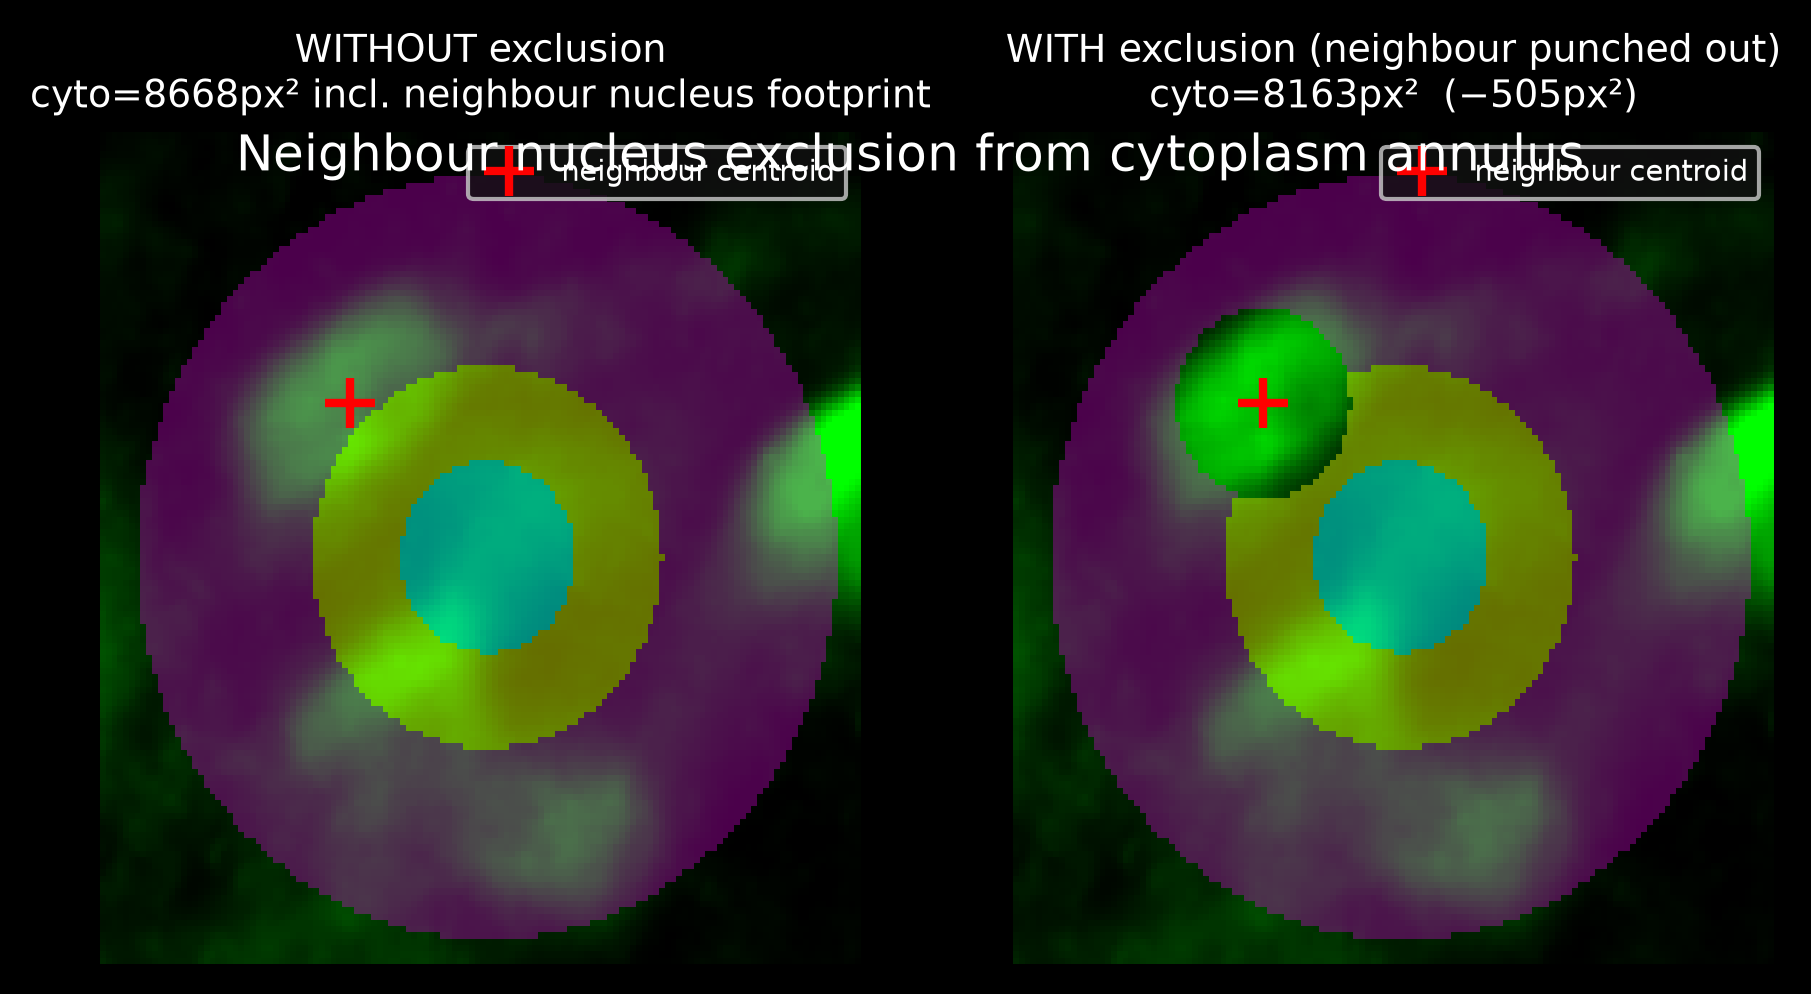

Exclusion removes 505 px² from cytoplasm annulus
Without exclusion: neighbour nucleus 71 leaks TDP-43 into cell 23's cytoplasm → suppressed N:C


In [4]:
# Show the problem and solution: two nearby cells, cytoplasm rings overlap

# Find two nearby nuclei
site_df_sorted = site_df.sort_values('area', ascending=False).reset_index(drop=True)
# Pick two nuclei close together
from scipy.spatial import distance_matrix
centroids = site_df_sorted[['centroid-0','centroid-1']].values
dm = distance_matrix(centroids, centroids)
np.fill_diagonal(dm, 999)
min_pair = np.unravel_index(dm.argmin(), dm.shape)
i1, i2 = min_pair
n1 = site_df_sorted.iloc[i1]
n2 = site_df_sorted.iloc[i2]
print(f"Pair: nucleus {i1} centroid=({n1['centroid-0']:.0f},{n1['centroid-1']:.0f})  "
      f"nucleus {i2} centroid=({n2['centroid-0']:.0f},{n2['centroid-1']:.0f})  "
      f"dist={dm[i1,i2]:.0f}px = {dm[i1,i2]*PX_UM:.1f}µm")

# Build crops around n1 with and without exclusion
cy1, cx1 = float(n1['centroid-0']), float(n1['centroid-1'])
cy2, cx2 = float(n2['centroid-0']), float(n2['centroid-1'])
R_full = int(np.ceil(R_CYTO)) + 5
y0, y1 = max(0, int(cy1)-R_full), min(tdp_img.shape[0], int(cy1)+R_full)
x0, x1 = max(0, int(cx1)-R_full), min(tdp_img.shape[1], int(cx1)+R_full)
tile = tdp_img[y0:y1, x0:x1]

# Without exclusion (pass empty others list)
nuc_no, adj_no, cyto_no = build_masks(cy1, cx1, [], R_NUC, R_ADJ, R_CYTO, y0, y1, x0, x1)

# With exclusion (n2 is a neighbour)
nuc_ex, adj_ex, cyto_ex = build_masks(cy1, cx1, [(cy2, cx2)], R_NUC, R_ADJ, R_CYTO, y0, y1, x0, x1)

vmin, vmax = np.percentile(tile, [1, 99.5])
K2G = LinearSegmentedColormap.from_list('k2g', ['black','lime'])

fig, axs = plt.subplots(1, 2, figsize=(7.2, 3.6), facecolor=BG, dpi=DPI)
fig.suptitle('Neighbour nucleus exclusion from cytoplasm annulus', color=FG, y=0.88)
for ax in axs: ax.set_facecolor(BG); ax.axis('off'); [s.set_color(FG) for s in ax.spines.values()]

def _overlay(tile, nuc_m, adj_m, cyto_m):
    ov = np.zeros((*tile.shape, 4), dtype=np.float32)
    ov[nuc_m]  = [0, 1, 1, 0.5]
    ov[adj_m]  = [1, 1, 0, 0.4]
    ov[cyto_m] = [1, 0, 1, 0.3]
    return ov

axs[0].imshow(tile, cmap=K2G, vmin=vmin, vmax=vmax, aspect='auto', interpolation='none')
axs[0].imshow(_overlay(tile, nuc_no, adj_no, cyto_no), aspect='auto', interpolation='none')
axs[0].set_title(f'WITHOUT exclusion\ncyto={cyto_no.sum()}px² incl. neighbour nucleus footprint',
                 color=FG, fontsize=9)

axs[1].imshow(tile, cmap=K2G, vmin=vmin, vmax=vmax, aspect='auto', interpolation='none')
axs[1].imshow(_overlay(tile, nuc_ex, adj_ex, cyto_ex), aspect='auto', interpolation='none')
axs[1].set_title(f'WITH exclusion (neighbour punched out)\ncyto={cyto_ex.sum()}px²  '
                 f'(−{cyto_no.sum()-cyto_ex.sum()}px²)', color=FG, fontsize=9)

# Mark second nucleus centroid
lcy2, lcx2 = cy2-y0, cx2-x0
for ax in axs:
    ax.plot(lcx2, lcy2, 'r+', ms=12, mew=2, label='neighbour centroid')
    ax.legend(fontsize=7, labelcolor=FG, facecolor='#111')

fig.savefig(FIGDIR / '03_neighbour_exclusion.png', dpi=DPI, bbox_inches='tight', facecolor=BG)
plt.show()
print(f"Exclusion removes {cyto_no.sum()-cyto_ex.sum()} px² from cytoplasm annulus")
print(f"Without exclusion: neighbour nucleus {i2} leaks TDP-43 into cell {i1}'s cytoplasm → suppressed N:C")

## Full Compartment Overlay on TDP-43 — Representative Cells

Site TDP-43 cells: 97  NC_ratio range: 0.36–49.21
Showing 6 cells: NC_ratio = [ 0.35614352  0.35815788  0.51830375 46.51389971 48.97716434 49.20733769]


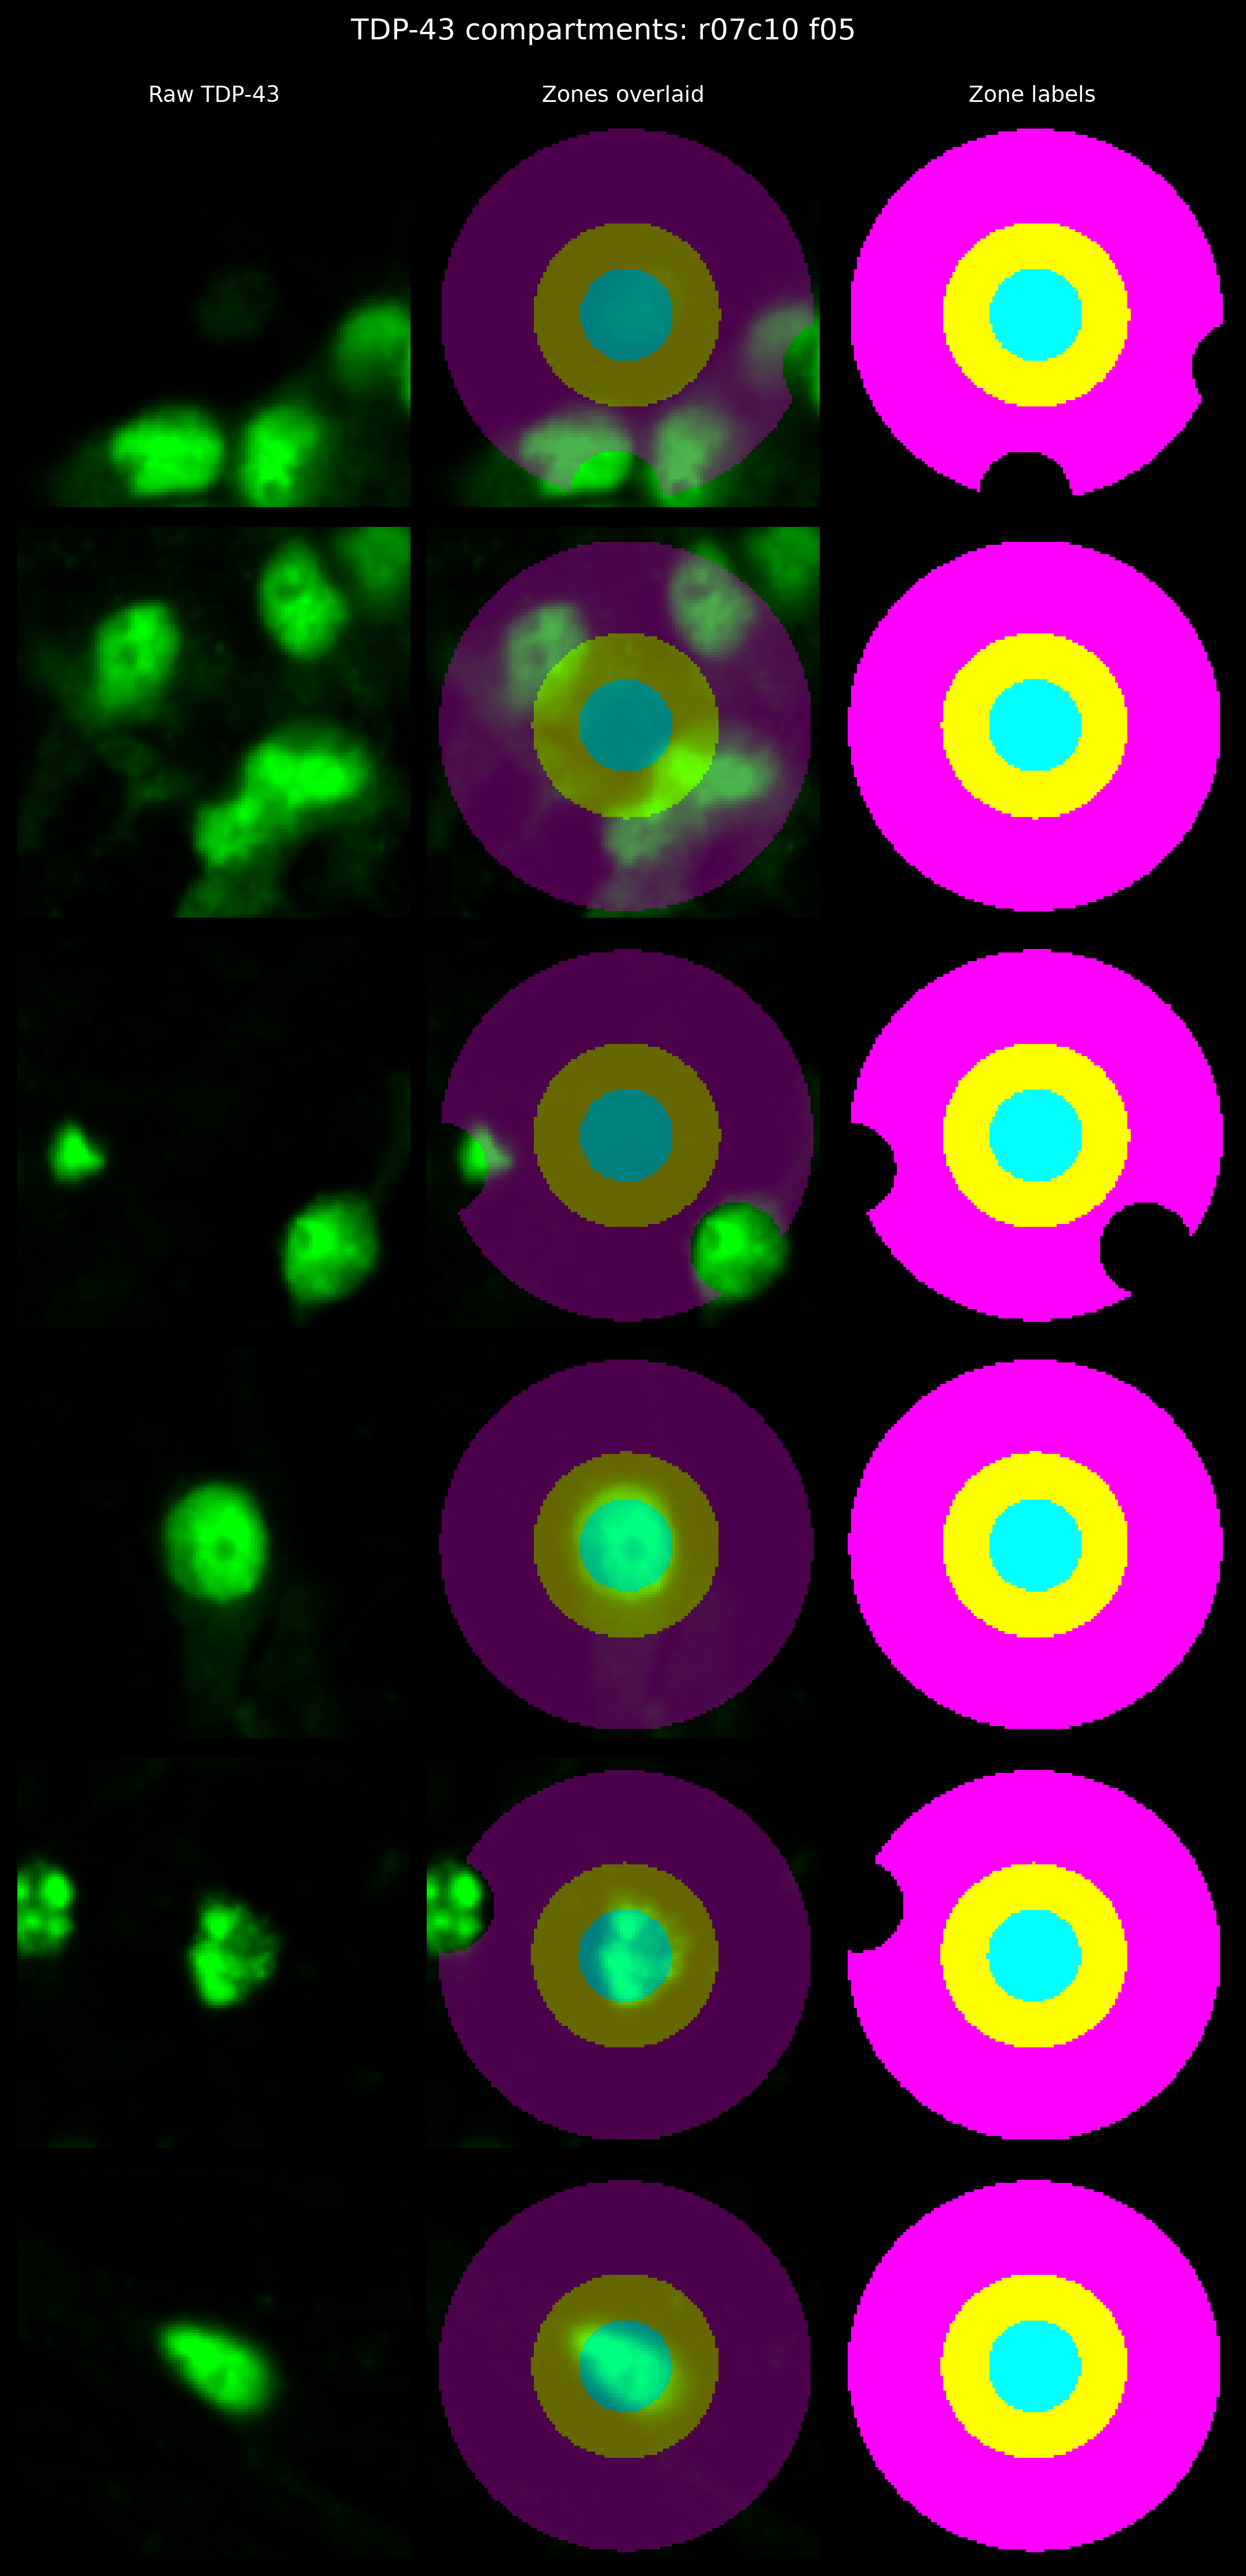

Saved: 04_compartment_overlay_cells.png


In [5]:
# Pick 6 cells with a range of NC_ratio (mix of high and low)
# Use TDP-43 parquet to get NC_ratio for this site
tdp_site = df_tdp[(df_tdp.Row==row) & (df_tdp.Column==col) & (df_tdp.Frame==frame)].copy()
tdp_site = tdp_site[(tdp_site.NC_ratio > 0) & (tdp_site.NC_ratio < 50)].sort_values('NC_ratio')
print(f"Site TDP-43 cells: {len(tdp_site)}  NC_ratio range: {tdp_site.NC_ratio.min():.2f}–{tdp_site.NC_ratio.max():.2f}")

if len(tdp_site) < 6:
    # fallback to any site with enough cells
    site_counts_tdp = df_tdp.groupby(['Row','Column','Frame']).size()
    rc_tdp = site_counts_tdp.idxmax()
    row, col, frame = rc_tdp
    tdp_subdir = IMG_DIR / f'r{row:02d}c{col:02d}'
    tdp_paths = sorted(tdp_subdir.glob(f'r{row:02d}c{col:02d}f{frame:02d}p*-ch03t01.tiff'))
    if tdp_paths:
        tdp_planes = [tifffile.imread(p).astype(np.float32) for p in tdp_paths]
        focus_scores = [np.var(laplace(p)) for p in tdp_planes]
        best_z = int(np.argmax(focus_scores))
        tdp_img = tdp_planes[best_z]
    tdp_site = df_tdp[(df_tdp.Row==row) & (df_tdp.Column==col) & (df_tdp.Frame==frame)]
    tdp_site = tdp_site[(tdp_site.NC_ratio>0)&(tdp_site.NC_ratio<50)].sort_values('NC_ratio')

# Pick 6 cells: 3 low, 3 high NC
n_pick = min(6, len(tdp_site))
picks = pd.concat([tdp_site.head(n_pick//2), tdp_site.tail(n_pick - n_pick//2)])
picks = picks.drop_duplicates().reset_index(drop=True)
print(f"Showing {len(picks)} cells: NC_ratio = {picks.NC_ratio.values}")

all_others = df_tdp[(df_tdp.Row==row)&(df_tdp.Column==col)&(df_tdp.Frame==frame)][['centroid-0','centroid-1']].values

CROP2 = 64  # px half-width
K2G   = LinearSegmentedColormap.from_list('k2g', ['black','lime'])
n_rows = len(picks)

fig, axs = plt.subplots(n_rows, 3, figsize=(9, n_rows*3+1), facecolor=BG, dpi=DPI)
if n_rows == 1: axs = axs[np.newaxis, :]
fig.suptitle(f'TDP-43 compartments: r{row:02d}c{col:02d} f{frame:02d}', color=FG, y=0.88)
plt.subplots_adjust(hspace=0.05, wspace=0.04, top=0.85)

col_titles = ['Raw TDP-43', 'Zones overlaid', 'Zone labels']

for ri, (_, cell_row) in enumerate(picks.iterrows()):
    cy_c = float(cell_row['centroid-0']); cx_c = float(cell_row['centroid-1'])
    nc   = float(cell_row['NC_ratio'])
    y0c, y1c = int(max(0, cy_c-CROP2)), int(min(tdp_img.shape[0], cy_c+CROP2))
    x0c, x1c = int(max(0, cx_c-CROP2)), int(min(tdp_img.shape[1], cx_c+CROP2))
    crop = tdp_img[y0c:y1c, x0c:x1c]

    others_yx = [(float(oy), float(ox)) for oy, ox in all_others
                 if abs(oy-cy_c) < (R_CYTO+R_NUC) and abs(ox-cx_c) < (R_CYTO+R_NUC)]

    nuc_m, adj_m, cyto_m = build_masks(cy_c, cx_c, others_yx, R_NUC, R_ADJ, R_CYTO, y0c, y1c, x0c, x1c)
    vmin, vmax = np.percentile(crop, [1, 99.5])

    for ci in range(3):
        ax = axs[ri, ci]
        ax.set_facecolor(BG); ax.axis('off')
        for s in ax.spines.values(): s.set_color(FG)
        if ri == 0: ax.set_title(col_titles[ci], color=FG, fontsize=9)

        ax.imshow(crop, cmap=K2G, vmin=vmin, vmax=vmax, aspect='auto', interpolation='none')
        if ci == 1:
            ov = np.zeros((*crop.shape, 4), dtype=np.float32)
            ov[nuc_m] = [0,1,1,0.5]; ov[adj_m] = [1,1,0,0.4]; ov[cyto_m] = [1,0,1,0.3]
            ax.imshow(ov, aspect='auto', interpolation='none')
        elif ci == 2:
            zone_img = np.zeros((*crop.shape, 3), dtype=np.float32)
            zone_img[nuc_m]  = [0, 1, 1]    # cyan
            zone_img[adj_m]  = [1, 1, 0]    # yellow
            zone_img[cyto_m] = [1, 0, 1]    # magenta
            ax.imshow(zone_img, aspect='auto', interpolation='none')

    lbl = f"N:C={nc:.2f}"
    col_lbl = '#ff4444' if nc < 4 else '#88ff88'
    axs[ri, 0].set_ylabel(lbl, color=col_lbl, fontsize=9, rotation=0, labelpad=55, va='center')

fig.savefig(FIGDIR / '04_compartment_overlay_cells.png', dpi=DPI, bbox_inches='tight', facecolor=BG)
plt.show()
print("Saved: 04_compartment_overlay_cells.png")

In [6]:
# Verify figures
pngs = sorted(FIGDIR.glob('*.png'))
empty = [p for p in pngs if p.stat().st_size == 0]
assert pngs,  f"No figures written to {FIGDIR}"
assert not empty, f"0-byte figures: {empty}"
print(f"OK: {len(pngs)} figures in {FIGDIR.name}/")
for p in pngs:
    print(f"  {p.name}  ({p.stat().st_size//1024} KB)")

OK: 4 figures in phase_C/
  01_nucleus_erosion.png  (86 KB)
  02_three_compartments.png  (124 KB)
  03_neighbour_exclusion.png  (100 KB)
  04_compartment_overlay_cells.png  (227 KB)
